In [11]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import json
from prophet.serialize import model_to_json

In [3]:
df_rain = pd.read_csv('./data/rainfall.csv')
df_sun = pd.read_csv('./data/sunshine.csv')
df = pd.merge(df_rain, df_sun, on='month', how='inner')

df['ds'] = pd.to_datetime(df['month'])
df = df.sort_values('ds').reset_index(drop=True)

## Rainfall forcasting model

In [4]:
# rainfall forcasting model
df_rain_prophet = df[['ds', 'no_of_rainy_days']].rename(columns={'no_of_rainy_days': 'y'})

model_rain = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_rain.fit(df_rain_prophet)

future_dates = model_rain.make_future_dataframe(periods=12, freq='MS')

forecast_rain = model_rain.predict(future_dates)

01:54:33 - cmdstanpy - INFO - Chain [1] start processing
01:54:35 - cmdstanpy - INFO - Chain [1] done processing


## Sunshine forcasting model

In [5]:
# primary sunshine forcasting model
df_sun_prophet = df[['ds', 'mean_sunshine_hrs', 'no_of_rainy_days']].rename(columns={'mean_sunshine_hrs': 'y'})
model_sun = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

model_sun.add_regressor('no_of_rainy_days')
model_sun.fit(df_sun_prophet)

01:55:30 - cmdstanpy - INFO - Chain [1] start processing
01:55:30 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
# final sunshine forcasting model
future_sun = forecast_rain[['ds', 'yhat']].copy()
future_sun = future_sun.rename(columns={'yhat': 'no_of_rainy_days'})
forecast_sun = model_sun.predict(future_sun)

final_predictions = forecast_sun[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
final_predictions = final_predictions.rename(columns={'yhat': 'Predicted_Sunshine_Hrs'})

print(final_predictions)

            ds  Predicted_Sunshine_Hrs  yhat_lower  yhat_upper
530 2026-03-01                6.542302    5.608646    7.483080
531 2026-04-01                6.174321    5.213154    7.142844
532 2026-05-01                6.044607    5.087786    7.016422
533 2026-06-01                6.123947    5.022726    7.065606
534 2026-07-01                6.295914    5.413605    7.254359
535 2026-08-01                5.960188    5.025944    6.896564
536 2026-09-01                5.391564    4.447637    6.332838
537 2026-10-01                5.358830    4.411445    6.316713
538 2026-11-01                4.642937    3.707730    5.588041
539 2026-12-01                4.408646    3.375182    5.249450
540 2027-01-01                5.740550    4.755538    6.704322
541 2027-02-01                7.187933    6.249116    8.185522


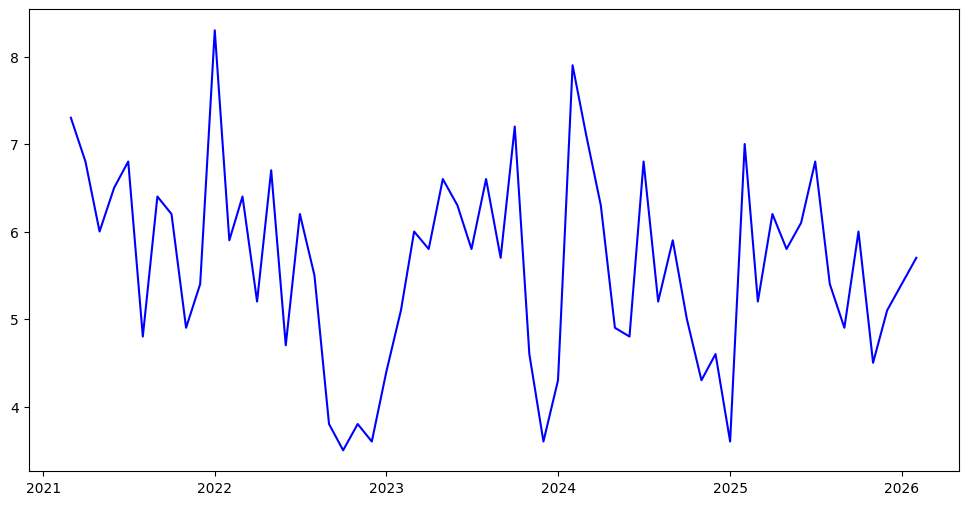

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['ds'][-60:], df['mean_sunshine_hrs'][-60:], label='Historical Sunshine', color='blue')

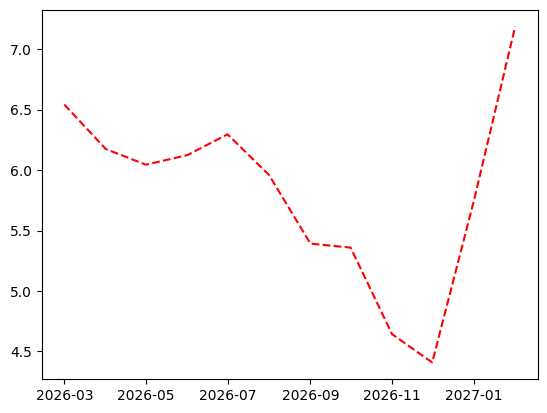

In [8]:
plt.plot(final_predictions['ds'], final_predictions['Predicted_Sunshine_Hrs'], label='Forecasted Sunshine (Next 12 Months)', color='red', linestyle='--')

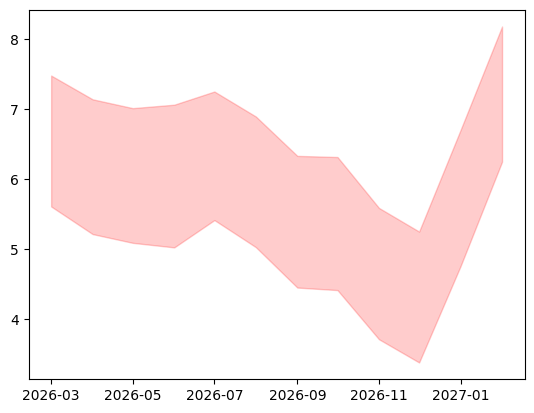

In [9]:
plt.fill_between(final_predictions['ds'], final_predictions['yhat_lower'], final_predictions['yhat_upper'], color='red', alpha=0.2, label='Uncertainty Interval')

In [12]:
with open('./model/model_rain.json', 'w') as fout:
    json.dump(model_to_json(model_rain), fout)
with open('./model/model_sun.json', 'w') as fout:
    json.dump(model_to_json(model_sun), fout)

print("Models successfully saved as 'model_rain.json' and 'model_sun.json'!")

Models successfully saved as 'model_rain.json' and 'model_sun.json'!


## Electricity price forcasting model

In [13]:
def train_and_save_tariff_model(df, series_name, output_json_name):
    df_filtered = df[df['DataSeries'] == series_name].copy()
    if df_filtered.empty:
        print(f"Warning: No data found for {series_name}")
        return None

    df_long = df_filtered.melt(id_vars=['DataSeries'], var_name='month_str', value_name='price')
    df_long['ds'] = pd.to_datetime(df_long['month_str'], format='%Y%b')
    df_prophet = df_long[['ds', 'price']].rename(columns={'price': 'y'})
    df_prophet = df_prophet.dropna().sort_values('ds').reset_index(drop=True)

    print(f"Training Prophet model for {series_name}...")
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(df_prophet)

    future_dates = model.make_future_dataframe(periods=12, freq='MS')
    forecast = model.predict(future_dates)

    with open(output_json_name, 'w') as fout:
        json.dump(model_to_json(model), fout)
    print(f"Model successfully saved as '{output_json_name}'!")

    return df_prophet, forecast

In [14]:
df_all = pd.read_csv('./data/electricity.csv')

# Domestic
dom_data, dom_forecast = train_and_save_tariff_model(
    df=df_all,
    series_name='Low Tension Supplies - Domestic',
    output_json_name='./model/tariff_domestic.json'
)

# Non-Domestic
ind_data, ind_forecast = train_and_save_tariff_model(
    df=df_all,
    series_name='Low Tension Supplies - Non-Domestic',
    output_json_name='./model/tariff_industrial.json'
)

02:15:21 - cmdstanpy - INFO - Chain [1] start processing
02:15:21 - cmdstanpy - INFO - Chain [1] done processing
02:15:21 - cmdstanpy - INFO - Chain [1] start processing
02:15:21 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet model for Low Tension Supplies - Domestic...
Model successfully saved as './model/tariff_domestic.json'!
Training Prophet model for Low Tension Supplies - Non-Domestic...
Model successfully saved as './model/tariff_industrial.json'!


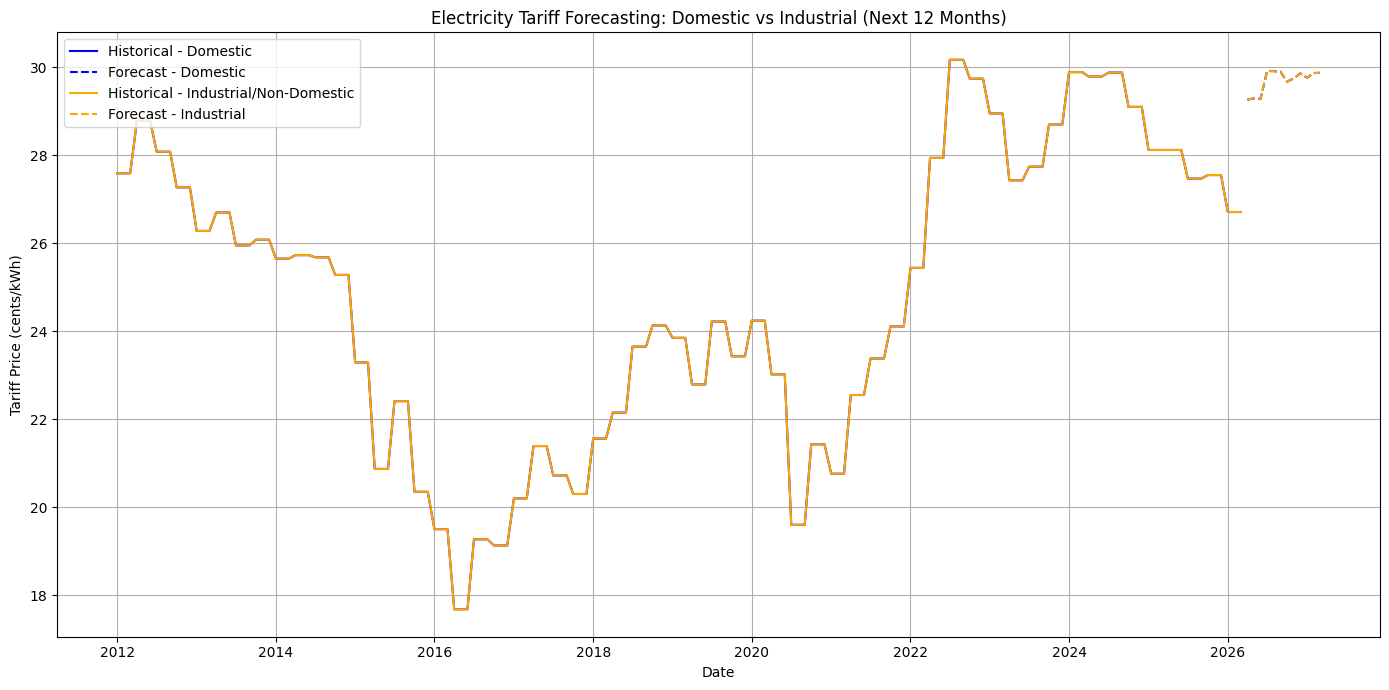

In [15]:
plt.figure(figsize=(14, 7))

plt.plot(dom_data['ds'], dom_data['y'], label='Historical - Domestic', color='blue')
dom_future = dom_forecast.tail(12)
plt.plot(dom_future['ds'], dom_future['yhat'], label='Forecast - Domestic', color='blue', linestyle='--')

plt.plot(ind_data['ds'], ind_data['y'], label='Historical - Industrial/Non-Domestic', color='orange')
ind_future = ind_forecast.tail(12)
plt.plot(ind_future['ds'], ind_future['yhat'], label='Forecast - Industrial', color='orange', linestyle='--')

plt.title('Electricity Tariff Forecasting: Domestic vs Industrial (Next 12 Months)')
plt.xlabel('Date')
plt.ylabel('Tariff Price (cents/kWh)')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()